# Predicting Emergency Room Wait Time Using Machine Learning

## The Problem

In emergency rooms, time is critical. Long waiting times can increase patient stress, reduce satisfaction, and in some cases, negatively affect health outcomes.

However, patient wait time is not random. It is influenced by multiple factors such as patient age, department referral, admission status, hospital workload, and other operational conditions.

Hospitals often struggle to anticipate peak congestion periods or identify which factors contribute most to long delays. Without predictive insights, managing resources efficiently becomes challenging, leading to overcrowding and reduced quality of service.

### The Solution

In this project, we develop a regression model to predict patient wait time in the emergency room using historical hospital data.

The dataset includes patient demographics, admission details, referral departments, and satisfaction scores. By analyzing these variables, we aim to:

- Identify **key factors** that drive **longer waiting times**.
- Provide **insights** that support **better hospital resource planning**.
- **Predict expected wait time** for incoming patients


Our goal is not only to build an accurate predictive model, but also to generate actionable insights that can help hospitals:
- Improve resource allocation
- Reduce overcrowding
- Enhance patient satisfaction
- Make data-driven operational decisions

This project demonstrates how machine learning can be applied to real-world healthcare challenges, transforming raw hospital records into meaningful predictions that improve both operational efficiency and patient experience.

## Project Features Description

| Feature Name | Description |
|--------------|------------|
| `patient_id` | Unique identifier for each patient|
| `patient_admission_date` | Date of emergency room visit (day, month, weekday, etc.)|
| `patient_first_initial` | First letter of patient’s first name (Privacy Related)|
| `patient_last_name` | Patient’s last name |
| `patient_gender` | Gender of the patient |
| `patient_age` | Age of the patient (in years)|
| `patient_race` | Patient’s race category |
| `department_referral` | Department that referred the patient|
| `patient_admission_flag` | Indicates whether the patient was admitted (Yes/No) |
| `patient_satisfaction_score` | Patient satisfaction rating (Ordinal)|
| `patient_waittime` | Waiting time in minutes|
| `patients_cm` | Representing the presence or absence of a specific case/capacity condition related to the patient visit|

## Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
# from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold ,cross_val_score


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [65]:
import numpy as np
from sklearn.metrics import mean_squared_error


def mape_percent_eps(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


def eval_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape_percent_eps(y_true, y_pred),
    }


## Import Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laxdippatel/hospital-emergency-room-dataset")

print("Path to dataset files:", path)

100%|██████████| 223k/223k [00:00<00:00, 725kB/s]

Extracting files...
Path to dataset files: C:\Users\osama\.cache\kagglehub\datasets\laxdippatel\hospital-emergency-room-dataset\versions\1


In [5]:
# List all files in the downloaded directory
files = os.listdir(path)
print("Files in dataset:", files)

Files in dataset: ['Hospital ER_Data.csv']


In [6]:
df = pd.read_csv(os.path.join(path, files[0]))

print(df.shape)

(9216, 12)


In [7]:
# Shows the first 5 rows of the data
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


## Split Data into Train and Test

In [8]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [9]:
train_data.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM'],
      dtype='str')

In [10]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 7372 entries, 4541 to 7270
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  7372 non-null   str    
 1   Patient Admission Date      7372 non-null   str    
 2   Patient First Inital        7372 non-null   str    
 3   Patient Last Name           7372 non-null   str    
 4   Patient Gender              7372 non-null   str    
 5   Patient Age                 7372 non-null   int64  
 6   Patient Race                7372 non-null   str    
 7   Department Referral         3025 non-null   str    
 8   Patient Admission Flag      7372 non-null   bool   
 9   Patient Satisfaction Score  2040 non-null   float64
 10  Patient Waittime            7372 non-null   int64  
 11  Patients CM                 7372 non-null   int64  
dtypes: bool(1), float64(1), int64(3), str(7)
memory usage: 698.3 KB


In [11]:
train_data.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime,Patients CM
count,7372.000000,2040.000000,7372.000000,7372.000000
mean,40.074200,4.918137,35.162642,0.054666
std,22.863436,3.141062,14.756128,0.227343
min,1.000000,0.000000,10.000000,0.000000
25%,20.000000,2.000000,22.000000,0.000000
50%,40.000000,5.000000,35.000000,0.000000
75%,60.000000,8.000000,48.000000,0.000000
max,79.000000,10.000000,60.000000,1.000000


## Feature Exploration

In [12]:
train_data['Patient Id'].head()

4541    625-63-4515
2770    180-76-2943
7537    418-90-7502
8113    363-78-2720
402     306-08-1494
Name: Patient Id, dtype: str

**Note**
- `Patient Id` is just an indentifier, so we can **drop** it.

In [13]:
train_data['Patient Admission Date'].head()

4541    21-12-2023 20:26
2770    15-06-2024 19:14
7537    27-10-2023 08:33
8113    12-07-2024 07:02
402     22-05-2023 09:41
Name: Patient Admission Date, dtype: str

**Note**
- In `Patient Admission Date`, The datatype isn't correct. So It should be converted to **datetime format**.
- Also, We can extract useful features from this column like:
  - Day
  - Month
  - Year
  - Hour
  - Minutes

In [14]:
train_data[['Patient First Inital', 'Patient Last Name']].head()

,Patient First Inital,Patient Last Name
4541,F,Merriment
2770,X,Zarfai
7537,C,Janca
8113,O,Ferraresi
402,C,MacInnes


**Note**
- `Patient First Inital`, `Patient Last Name` doesn't matter the model alot and it's a privacy concern, so we can **drop** them.

In [15]:
train_data['Patient Gender'].value_counts()

Patient Gender
M     3770
F     3584
NC      18
Name: count, dtype: int64

**Note**
- `Patient Gender` It's a **categorical** column.
  - M refers to Male.
  - F refers to Female.
  - NC refers to Not Confirmed or Not Classified.

In [16]:
train_data['Patient Age'].head()

4541    57
2770     1
7537     2
8113    37
402     69
Name: Patient Age, dtype: int64

In [17]:
train_data['Patient Age'].describe()

count    7372.000000
mean       40.074200
std        22.863436
min         1.000000
25%        20.000000
50%        40.000000
75%        60.000000
max        79.000000
Name: Patient Age, dtype: float64

**Note**
- `Patient Age` it's **mean and median** are really **close** to each other. Nearly to **Normal Distribution**.
- We can **scale** it in the **preprocessing step**.

In [18]:
train_data['Patient Race'].value_counts()

Patient Race
White                            2062
African American                 1555
Two or More Races                1239
Asian                             849
Declined to Identify              809
Pacific Islander                  441
Native American/Alaska Native     417
Name: count, dtype: int64

**Note**
- `Patient Race` is a **categorical** column.
- We need to **encode** it.

In [19]:
train_data['Department Referral'].value_counts()

Department Referral
General Practice    1452
Orthopedics          775
Physiotherapy        222
Cardiology           209
Neurology            153
Gastroenterology     141
Renal                 73
Name: count, dtype: int64

**Note**
- `Department Referral` is a **categorical** column.
- We need to **encode** it.

In [20]:
train_data['Patient Admission Flag'].value_counts()

Patient Admission Flag
False    3686
True     3686
Name: count, dtype: int64

**Note**
- `Patient Admission Flag` is a **categorical** column.

In [21]:
train_data['Patient Satisfaction Score'].value_counts()

Patient Satisfaction Score
1.0     212
7.0     202
4.0     200
3.0     194
6.0     183
5.0     182
10.0    181
0.0     178
9.0     175
2.0     172
8.0     161
Name: count, dtype: int64

**Note**
- `Patient Satisfaction Score` is an **ordinal** column and It takes values **from 1 to 10**.
- But It's a **Post-visit** column so, We will **drop** it to avoid data leakage.

In [22]:
train_data['Patient Waittime'].head()

4541    52
2770    29
7537    34
8113    50
402     60
Name: Patient Waittime, dtype: int64

In [23]:
train_data['Patient Waittime'].describe()

count    7372.000000
mean       35.162642
std        14.756128
min        10.000000
25%        22.000000
50%        35.000000
75%        48.000000
max        60.000000
Name: Patient Waittime, dtype: float64

**Note**
- `Patient Waittime` it's **mean and median** are really **close** to each other.
- Refers to nearly **Normal Distribution**.

In [24]:
train_data['Patients CM'].value_counts()

Patients CM
0    6969
1     403
Name: count, dtype: int64

**Note**
- `Patients CM` is a categorical column.
  - **One** means the condition is **present**.
  - **Zero** means the condition is **absent**.

### Check for Missing Values

In [25]:
train_data.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           4347
Patient Admission Flag           0
Patient Satisfaction Score    5332
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [23]:
train_data.isnull().sum() / len(train_data) * 100

,0
Patient Id,0.000000
Patient Admission Date,0.000000
Patient First Inital,0.000000
Patient Last Name,0.000000
Patient Gender,0.000000
Patient Age,0.000000
Patient Race,0.000000
Department Referral,58.966359
Patient Admission Flag,0.000000
Patient Satisfaction Score,72.327727


**Note**
- `Department Referral` and `Patient Satisfaction Score` contain a lot of missing values.
- `Patient Satisfaction Score` will be dropped (post-visit column).
- `Department Referral` will be imputed with the most frequent value.

## EDA - Exploratory Data Analysis

### Distribution of Target Column (Wait Time)

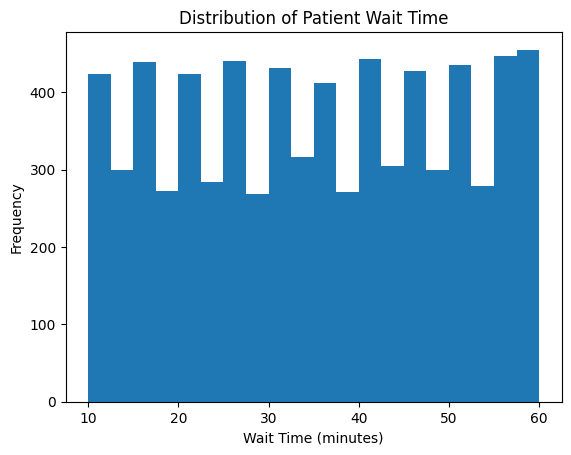

In [26]:
plt.hist(train_data['Patient Waittime'], bins=20)
plt.title('Distribution of Patient Wait Time')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Frequency')
plt.show()

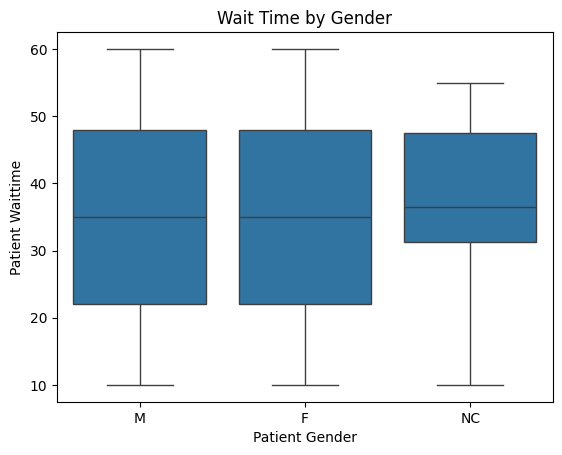

In [27]:
sns.boxplot(x='Patient Gender', y='Patient Waittime', data=train_data)
plt.title('Wait Time by Gender')
plt.show()

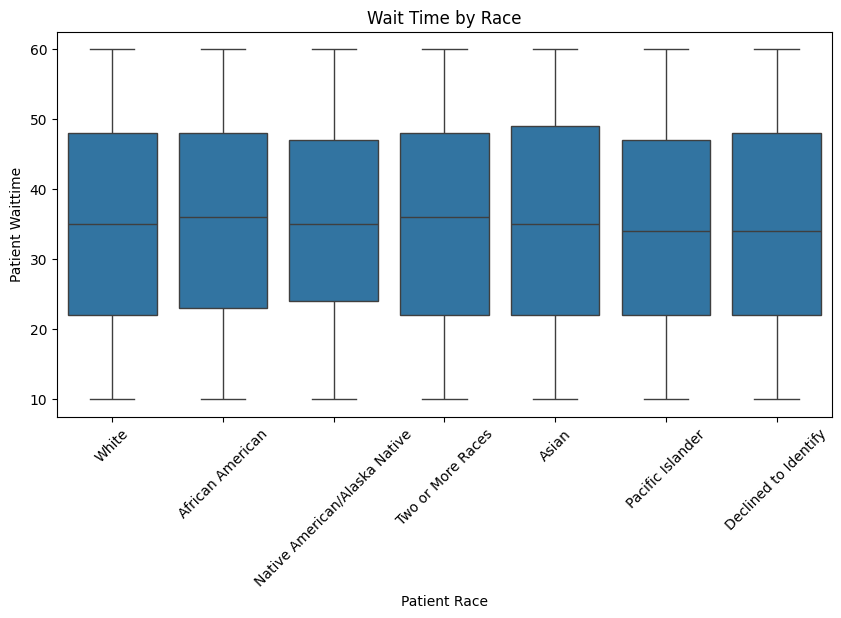

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Patient Race', y='Patient Waittime', data=train_data)
plt.xticks(rotation=45)
plt.title('Wait Time by Race')
plt.show()

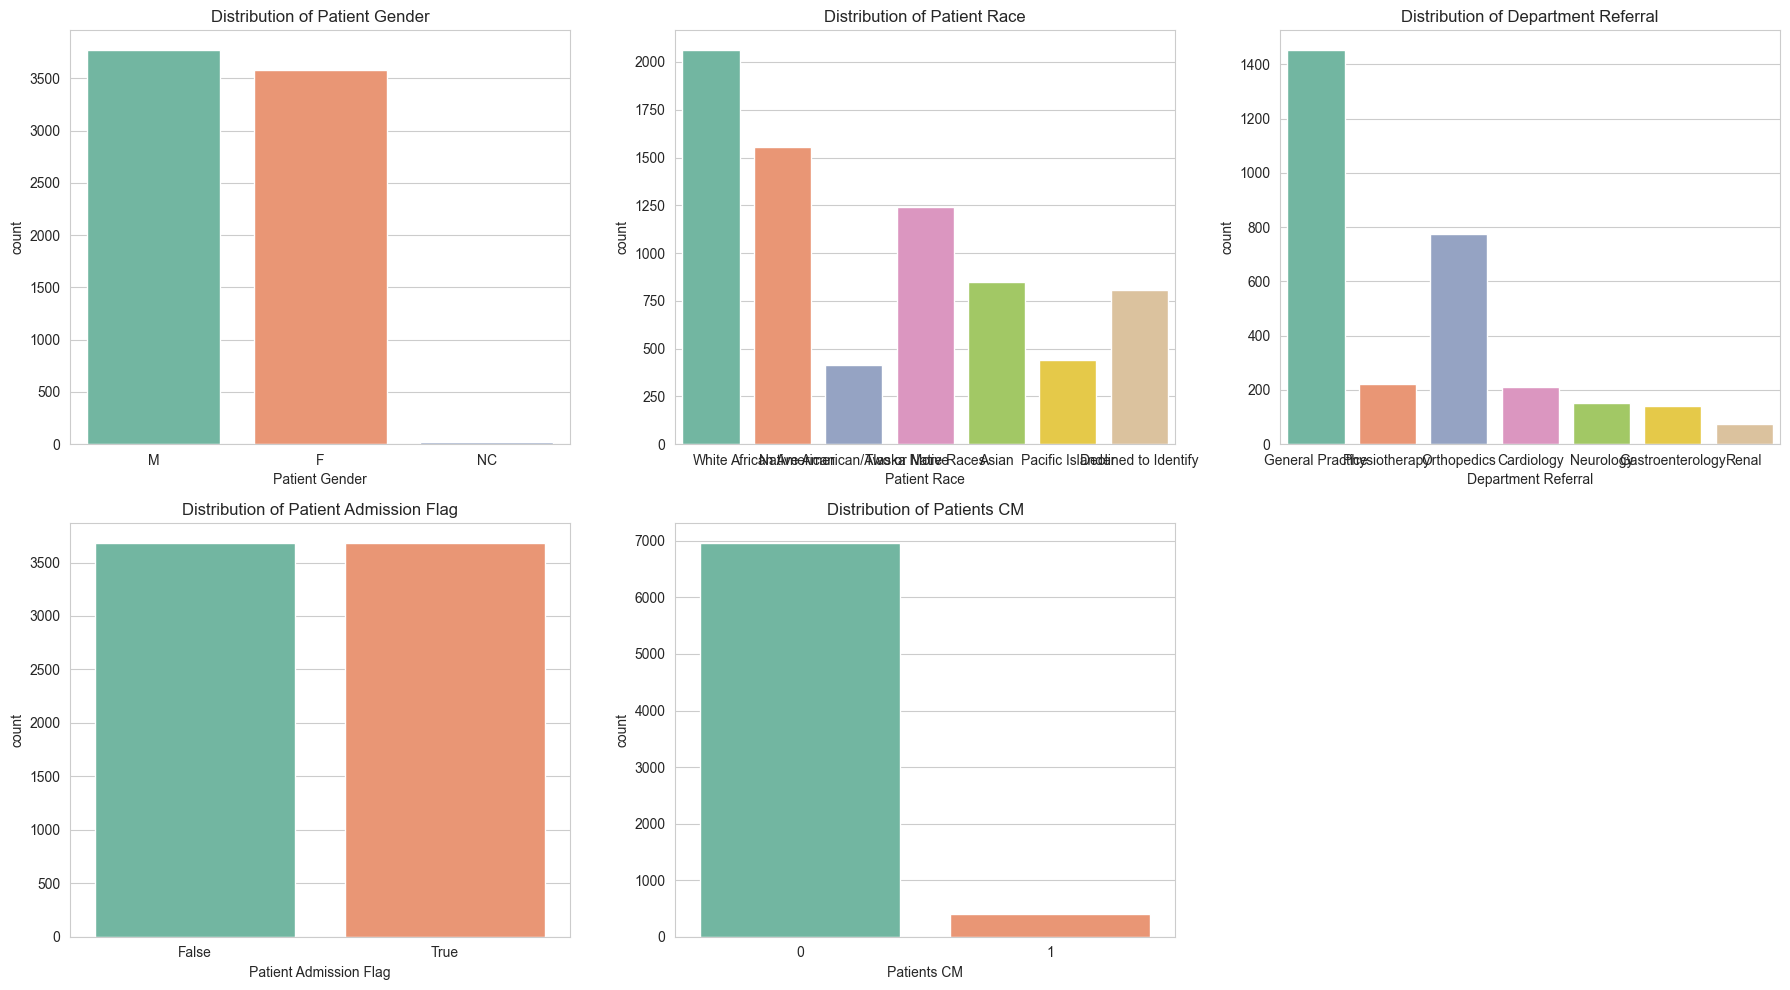

In [29]:
# Categorical columns to plot
columns = [
    'Patient Gender',
    'Patient Race',
    'Department Referral',
    'Patient Admission Flag',
    'Patients CM'
]

# Set style
sns.set_style("whitegrid")

# Create figure (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Custom color palette
palette = sns.color_palette("Set2")  # You can change this

# Plot each column
for i, col in enumerate(columns):
    sns.countplot(x=col, data=train_data, ax=axes[i], palette=palette)
    axes[i].set_title(f'Distribution of {col}')

    if df[col].dtype == 'object':
        axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

- **Insights for Patient Gender**
  - Male and Female patients are almost evenly distributed.
  - Very small percentage marked as NC (Not Classified / Not Confirmed).

- **Insights for Patient Race**
  - White patients form the largest group.
  - African American patients are the second largest.
  - This column in **imbalanced**.

- **Insights for Department Referrel**
  - General Practice dominates referrals (largest by far).
  - Orthopedics is the second most common.
  - Renal has the lowest referrals.

- **Insights for Patient Admission Flag**
  - This column is balanced.

- **Insights for Patients CM**
  - Majority are labeled 0 (No CM).
  - Very small portion labeled 1 (Has CM).
  - This is also **imbalanced** column.


## Data Cleaning

#### Unnecessary Columns to Drop
- Patient Id
- Patient First Inital
- Patient Last Name
- Patient Satisfaction Score

In [30]:
train_data.drop(columns=['Patient Id', 'Patient First Inital', 'Patient Last Name','Patient Satisfaction Score'], inplace=True)

#### Feature Engineering for Patient Admission Date

In [31]:
train_data['Patient Admission Date'] = pd.to_datetime(
    train_data['Patient Admission Date'],
    format='%d-%m-%Y %H:%M'
)

# Ensure chronological order for time-aware validation/CV
train_data = train_data.sort_values('Patient Admission Date').reset_index(drop=True)

In [32]:
# Extract Features
train_data['year'] = train_data['Patient Admission Date'].dt.year
train_data['month'] = train_data['Patient Admission Date'].dt.month
train_data['day'] = train_data['Patient Admission Date'].dt.day
train_data['hour'] = train_data['Patient Admission Date'].dt.hour
train_data['minute'] = train_data['Patient Admission Date'].dt.minute
train_data['day_of_week'] = train_data['Patient Admission Date'].dt.dayofweek

In [33]:
train_data.sample()

,Patient Admission Date,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Waittime,Patients CM,year,month,day,hour,minute,day_of_week
2115,2023-09-15 23:10:00,F,54,White,NaN,True,31,0,2023,9,15,23,10,4


In [34]:
train_data.drop(columns=['Patient Admission Date', 'day'], inplace=True)

In [35]:
train_data.sample()

,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Waittime,Patients CM,year,month,hour,minute,day_of_week
1241,M,30,Asian,Orthopedics,False,59,0,2023,7,1,13,3


#### Outliers

In [36]:
train_data = train_data[train_data['Patient Waittime'] < train_data['Patient Waittime'].quantile(0.97)]

#### Fill missing values

In [37]:
imputer = SimpleImputer(strategy='most_frequent')
train_data[['Department Referral']] = imputer.fit_transform(train_data[['Department Referral']])

train_data.isnull().sum()

Patient Gender            0
Patient Age               0
Patient Race              0
Department Referral       0
Patient Admission Flag    0
Patient Waittime          0
Patients CM               0
year                      0
month                     0
hour                      0
minute                    0
day_of_week               0
dtype: int64

#### Columns to encode
- Patient Gender
- Patient Race
- Department Referral

In [38]:
train_data.sample()

,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Waittime,Patients CM,year,month,hour,minute,day_of_week
5662,M,47,Declined to Identify,General Practice,False,15,0,2024,6,0,14,3


In [39]:
columns_to_encode = ['Patient Gender', 'Patient Race', 'Department Referral']

train_data = pd.get_dummies(train_data, columns=columns_to_encode, drop_first=True)
train_data.sample()

,Patient Age,Patient Admission Flag,Patient Waittime,Patients CM,year,month,hour,minute,day_of_week,Patient Gender_M,...,Patient Race_Native American/Alaska Native,Patient Race_Pacific Islander,Patient Race_Two or More Races,Patient Race_White,Department Referral_Gastroenterology,Department Referral_General Practice,Department Referral_Neurology,Department Referral_Orthopedics,Department Referral_Physiotherapy,Department Referral_Renal
2758,31,False,56,0,2023,11,8,17,5,True,...,False,True,False,False,False,True,False,False,False,False


#### Correlation with Target

In [40]:
train_data.corr(numeric_only=True)["Patient Waittime"].sort_values(ascending=False)

Patient Waittime                              1.000000
year                                          0.015462
Patient Gender_NC                             0.012942
Patient Gender_M                              0.011598
Department Referral_Neurology                 0.011473
Department Referral_Physiotherapy             0.006618
Department Referral_General Practice          0.006513
Patient Race_Two or More Races                0.003643
Patient Race_Asian                            0.001660
Patient Race_Native American/Alaska Native    0.000398
Patient Race_White                           -0.000202
hour                                         -0.000699
Department Referral_Gastroenterology         -0.001043
Department Referral_Renal                    -0.001220
Patient Age                                  -0.003894
minute                                       -0.005657
day_of_week                                  -0.008001
Patient Race_Declined to Identify            -0.008677
Patient Ra

#### Split Data into X (Features) and y (Label)

In [41]:
# Target
y = train_data['Patient Waittime']

# Features
X = train_data.drop(columns=['Patient Waittime'])

In [42]:
# Time-aware split (requires rows already sorted by admission datetime)
split_idx = int(len(X) * 0.9)

X_train = X.iloc[:split_idx].copy()
X_val   = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_val   = y.iloc[split_idx:].copy()

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)

X_train shape: (6368, 22)
X_val shape: (708, 22)


#### Scale Numerical Features

In [43]:
scaler = StandardScaler()

X_train[['Patient Age']] = scaler.fit_transform(X_train[['Patient Age']])
X_val[['Patient Age']]   = scaler.transform(X_val[['Patient Age']])

## Linear Regression (Baseline Model)

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R2 Score:", r2_score(y_val, y_pred))

MAE: 12.333299490103187
RMSE: 14.18839831417844
R2 Score: -0.0003417290021772157


## Lasso

In [47]:
model = Lasso(alpha=0.001)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Lasso R2:", r2_score(y_val, y_pred))

MAE: 12.333165249601603
RMSE: 14.187867903374306
Lasso R2: -0.00026693801711052956


## Ridge Regression

In [48]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Ridge R2:", r2_score(y_val, y_pred))

MAE: 12.333103577658463
RMSE: 14.188202317866457
Ridge R2: -0.00031409206514254606


## ElasticNet

In [49]:
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("ElasticNet R2:", r2_score(y_val, y_pred))

MAE: 12.336512944167351
RMSE: 14.182645153827842
ElasticNet R2: 0.00046935050669427714


## Decision Tree

In [50]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Decision Tree R2:", r2_score(y_val, y_pred))


MAE: 16.562146892655367
RMSE: 20.271393107802766
Decision Tree R2: -1.0419675348104018


## Random Forest

In [51]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Random Forest R2:", r2_score(y_val, y_pred))

MAE: 12.626497175141244
RMSE: 14.655247599525223
Random Forest R2: -0.06725441990620729


In [52]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Apply Log Transform
y_train_log = np.log1p(y_train)

# Train on the log values
model.fit(X_train, y_train_log)

# Predict and transform back
y_pred_log = model.predict(X_val)
y_pred = np.expm1(y_pred_log)

print("New RandomForest R2:", r2_score(y_val, y_pred))

New RandomForest R2: -0.1565661325511276


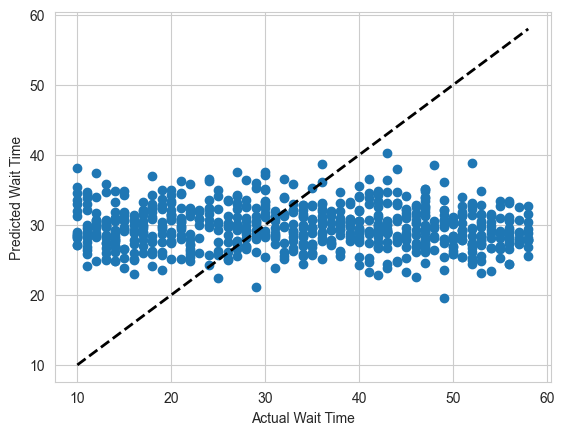

In [54]:
plt.scatter(y_val, y_pred)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)
plt.show()

## ExtraTreesRegressor

In [55]:
model = ExtraTreesRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Extra Trees R2:", r2_score(y_val, y_pred))

MAE: 12.712923728813559
RMSE: 14.735112457130885
Extra Trees R2: -0.0789182791451799


## Gradient Boosting

In [56]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("Gradient Boosting R2:", r2_score(y_val, y_pred))

MAE: 12.23423338574796
RMSE: 14.127074423828148
Gradient Boosting R2: 0.008286768084464935


## XGBoost

In [57]:
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R2 Score:", r2_score(y_val, y_pred))

MAE: 13.585887908935547
RMSE: 16.043362033315564
R2 Score: -0.2790055274963379


## LightGBM

In [58]:
model = LGBMRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("LightGBM R2:", r2_score(y_val, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 6368, number of used features: 21
[LightGBM] [Info] Start training from score 34.188442
MAE: 12.441563531497893
RMSE: 14.444062824323252
LightGBM R2: -0.03671737942452635


## Voting Regressor

In [59]:
voting_model = VotingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(random_state=42)),
        ('xgb',  XGBRegressor(random_state=42)),
        ('lgbm', LGBMRegressor())
    ]
)

voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_val)

print("MAE:     ", mean_absolute_error(y_val, y_pred))
print("RMSE:    ", mean_squared_error(y_val, y_pred) ** 0.5)
print("Voting R2:", r2_score(y_val, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 6368, number of used features: 21
[LightGBM] [Info] Start training from score 34.188442
MAE:      12.755914194658544
RMSE:     14.802476794171145
Voting R2: -0.0888057844295207


## Stacking Regressor

In [ ]:
stacking_model = StackingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(random_state=42)),
        ('xgb',  XGBRegressor(random_state=42)),
        ('lgbm', LGBMRegressor())
    ],
    final_estimator=LinearRegression()
)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_val)

print("MAE:      ", mean_absolute_error(y_val, y_pred))
print("RMSE:     ", mean_squared_error(y_val, y_pred) ** 0.5)
print("Stacking R2:", r2_score(y_val, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 6368, number of used features: 21
[LightGBM] [Info] Start training from score 34.188442
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 5094, number of used features: 20
[LightGBM] [Info] Start training from score 34.296820
[LightGBM] [Warning] Found whi

## Feature Importance

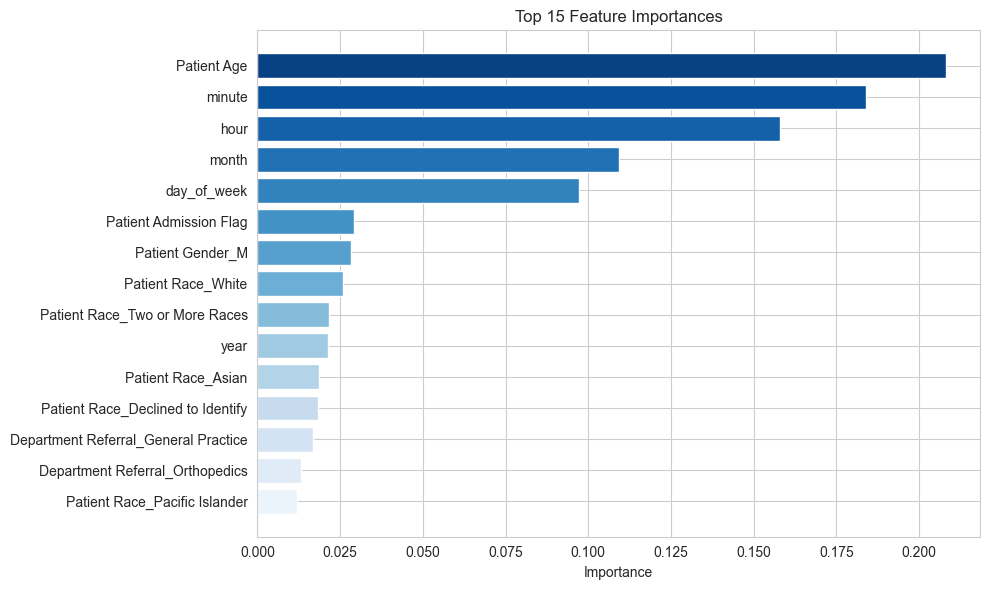

Top 5 features:
    feature  importance
Patient Age    0.207970
     minute    0.183845
       hour    0.157842
      month    0.109161
day_of_week    0.097179


In [61]:
fi = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_r', len(fi))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set(title='Top 15 Feature Importances', xlabel='Importance')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(fi.head(5).to_string(index=False))

## K-Fold Cross Validation

In [62]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Time-aware CV (requires rows already sorted by admission datetime)
tscv = TimeSeriesSplit(n_splits=5)

cv_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(),
}

print(f"{'Model':<22} {'Mean R²':>9} {'Std R²':>8}")
print("─" * 42)

for name, m in cv_models.items():
    scores = cross_val_score(m, X, y, cv=tscv, scoring="r2")
    print(f"{name:<22} {scores.mean():>9.4f} ± {scores.std():>6.4f}")

Model                    Mean R²   Std R²
──────────────────────────────────────────
Linear Regression        -0.0083 ± 0.0044
Random Forest            -0.0585 ± 0.0140
XGBoost                  -0.3138 ± 0.0853
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 19
[LightGBM] [Info] Start training from score 33.846740
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`

### Conclusion
- Dataset 1 features are **patient-level demographic and administrative** data.
- All models achieve **near-zero or slightly negative R²**, indicating that patient demographics and admission details alone are **not sufficient** to predict ER wait time accurately.
- This confirms the need to incorporate **operational features** (staffing, urgency level, facility size) from additional datasets, as planned in **Phase 2** of the project.

## Final Evaluation on Test Set

In [63]:
# Apply same preprocessing to test data (leak-safe: keep y separate)
raw_test = test_data.copy()
raw_test.drop(columns=['Patient Id', 'Patient First Inital', 'Patient Last Name', 'Patient Satisfaction Score'], inplace=True)

raw_test['Patient Admission Date'] = pd.to_datetime(raw_test['Patient Admission Date'], format='%d-%m-%Y %H:%M')
raw_test = raw_test.sort_values('Patient Admission Date').copy()

raw_test['year']        = raw_test['Patient Admission Date'].dt.year
raw_test['month']       = raw_test['Patient Admission Date'].dt.month
raw_test['hour']        = raw_test['Patient Admission Date'].dt.hour
raw_test['minute']      = raw_test['Patient Admission Date'].dt.minute
raw_test['day_of_week'] = raw_test['Patient Admission Date'].dt.dayofweek
raw_test.drop(columns=['Patient Admission Date'], inplace=True)

# Ground truth (keep before feature alignment)
y_test_true = raw_test['Patient Waittime'].copy()

X_test = raw_test.drop(columns=['Patient Waittime']).copy()
X_test[['Department Referral']] = imputer.transform(X_test[['Department Referral']])
X_test = pd.get_dummies(X_test, columns=['Patient Gender', 'Patient Race', 'Department Referral'], drop_first=True)

# Align columns with training features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Scale numeric columns using training-fitted scaler
X_test[['Patient Age']] = scaler.transform(X_test[['Patient Age']])

In [66]:
y_pred = rf_model.predict(X_test)

metrics = eval_regression(y_test_true, y_pred)
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")

R2:      -0.0747
MAE:     12.9887
RMSE:    15.1828
MAPE_%:  50.03


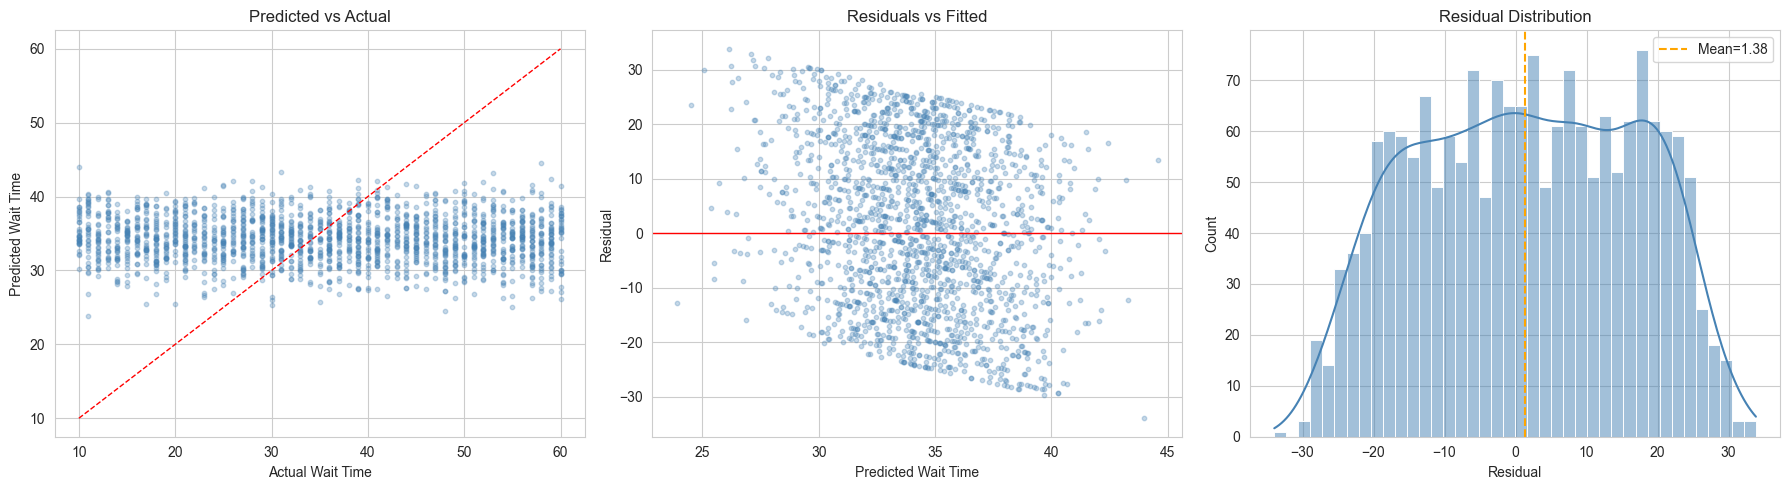

In [67]:
# Residual analysis (3-panel)
residuals = y_test_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Predicted vs Actual
axes[0].scatter(y_test_true, y_pred, alpha=0.3, s=10, color="steelblue")
axes[0].plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], "r--", linewidth=1)
axes[0].set(xlabel="Actual Wait Time", ylabel="Predicted Wait Time", title="Predicted vs Actual")

# 2) Residuals vs Fitted
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linewidth=1)
axes[1].set(xlabel="Predicted Wait Time", ylabel="Residual", title="Residuals vs Fitted")

# 3) Residual Distribution
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color="steelblue", edgecolor="white")
axes[2].axvline(residuals.mean(), color="orange", linewidth=1.5, linestyle="--", label=f"Mean={residuals.mean():.2f}")
axes[2].set(xlabel="Residual", title="Residual Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()